# Aula 04- Inferência Estatística com R

**Disciplina:** R para Ciência de Dados

**Professor:** Sérgio Monteiro, D.Sc.

**Pós-Graduação em Ciência de Dados**



# Uso Prático dos Exemplos

Os exemplos 01 a 05 foram construídos para ajudar na compreensão prática dos conceitos fundamentais de **Estatística Inferencial** e **Distribuições de Probabilidade**. Cada um deles tem uma aplicação direta em análises reais de dados.

### Objetivo Geral
Transformar conceitos teóricos abstratos em visualizações intuitivas e reprodutíveis, facilitando o aprendizado e a interpretação estatística.

### Explicação Prática de Cada Exemplo

**Exemplo 01: Erro Padrão vs Tamanho da Amostra**  
Mostra como o erro padrão da média diminui à medida que o tamanho da amostra aumenta.  
**Uso prático:**  
- Entender o impacto do tamanho da amostra na precisão das estimativas.  
- Decidir quantas observações são necessárias para obter um nível desejado de precisão em pesquisas e experimentos.

**Exemplo 02: Distribuição Normal Aproximada da Média Amostral**  
Visualiza a distribuição da média amostral conforme o Teorema Central do Limite.  
**Uso prático:**  
- Justificar o uso de métodos paramétricos mesmo quando a variável original não é normal.  
- Entender o comportamento da média em amostras grandes (muito comum em relatórios e testes de hipóteses).

**Exemplo 03: Área de Probabilidade**  
Calcula graficamente probabilidades sob a curva normal da média amostral (ex.: P(x̄ < 168)).  
**Uso prático:**  
- Resolver problemas de probabilidade envolvendo médias amostrais.  
- Interpretar resultados de testes de hipóteses e intervalos de confiança de forma visual.

**Exemplo 04: Distribuição Normal Padrão (Z)**  
Apresenta a distribuição normal padrão com as áreas clássicas (68% – 95% – 99,7%).  
**Uso prático:**  
- Padronizar variáveis (calcular escores Z).  
- Interpretar rapidamente probabilidades e valores críticos em tabelas Z.  
- Base para todos os testes estatísticos paramétricos (z-test, t-test, etc.).

**Exemplo 05: Variável Bernoulli**  
Simula e visualiza uma variável com apenas dois resultados (sucesso/fracasso).  
**Uso prático:**  
- Modelar eventos binários do dia a dia (clique em anúncio, aprovação em teste, cura de paciente, etc.).  
- Servir como base para distribuições mais complexas (Binomial, Geométrica, etc.).  
- Entender o conceito de probabilidade em simulações e Machine Learning.

---

### Resumo dos Benefícios

- **Visualização** → Facilita a compreensão intuitiva de conceitos difíceis.
- **Reprodutibilidade** → Todos os códigos podem ser executados e modificados facilmente.
- **Transição teórico-prática** → Conecta a teoria estatística com aplicações reais.
- **Preparação para tópicos avançados** → Prepara o aluno para Intervalos de Confiança, Testes de Hipóteses, Regressão e Machine Learning.



# **Exemplo 01: Erro Padrão da Média vs Tamanho da Amostra**

**Enunciado:**  
Analise como o **erro padrão da média** varia à medida que o tamanho da amostra aumenta.  
Considere uma população com desvio padrão σ = 10.

### Interpretação:

- O erro padrão diminui à medida que **n** aumenta.
- A redução segue a relação proporcional **1/√n**.
- A partir de determinado ponto, o ganho de precisão se torna marginal (lei dos rendimentos decrescentes).



Warning message in plot.window(...):
“"grid" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"grid" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"grid" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"grid" is not a graphical parameter”
Warning message in box(...):
“"grid" is not a graphical parameter”
Warning message in title(...):
“"grid" is not a graphical parameter”


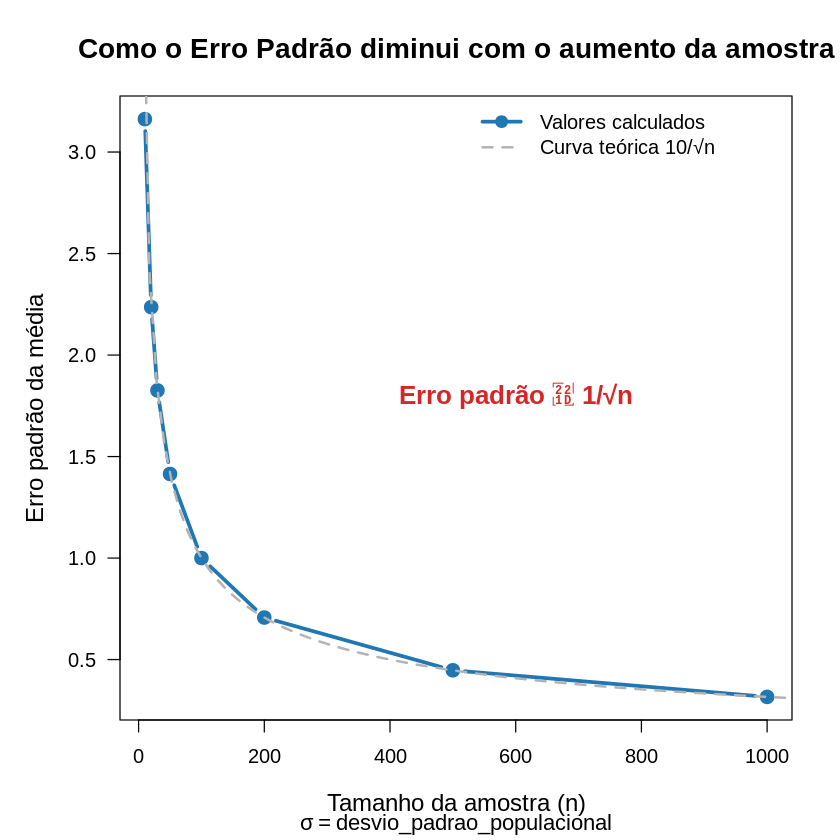

In [ ]:
# ================================================
# Exemplo 11: Erro Padrão da Média vs Tamanho da Amostra
# ================================================

# Definindo os tamanhos de amostra
n <- c(10, 20, 30, 50, 100, 200, 500, 1000)

# Erro padrão = 10 / sqrt(n)   (considerando desvio padrão populacional σ = 10)
desvio_padrao_populacional = 10
ep <- desvio_padrao_populacional / sqrt(n)

# Criando o gráfico com melhor qualidade visual
par(mar = c(5, 5, 4, 2))  # ajusta margens

plot(n, ep,
     type = "b",
     lwd = 3,
     col = "#1f77b4",
     pch = 19,
     cex = 1.2,
     xlab = "Tamanho da amostra (n)",
     ylab = "Erro padrão da média",
     main = "Como o Erro Padrão diminui com o aumento da amostra",
     sub = expression(sigma == desvio_padrao_populacional),
     cex.main = 1.4,
     cex.lab = 1.2,
     cex.sub = 1.1,
     las = 1,                    # deixa os números do eixo y na horizontal
     grid = TRUE)

# Adicionando linha de referência (proporcional a 1/sqrt(n))
curve(desvio_padrao_populacional / sqrt(x), from = 5, to = 1200,
      add = TRUE, col = "gray70", lty = 2, lwd = 2)

# Anotação explicativa
text(x = 600, y = 1.8,
     labels = "Erro padrão ∝ 1/√n",
     col = "#d62728",
     cex = 1.3,
     font = 2)

# Legenda
legend("topright",
       legend = c("Valores calculados", "Curva teórica 10/√n"),
       col = c("#1f77b4", "gray70"),
       lty = c(1, 2),
       lwd = c(3, 2),
       pch = c(19, NA),
       bty = "n")

# **Exemplo 02: Distribuição Normal Aproximada da Média Amostral**

**Enunciado:**  
Visualize a distribuição normal aproximada da **média amostral** segundo o Teorema Central do Limite.

### Parâmetros:
- Média populacional (μ) = 100  
- Desvio padrão populacional (σ) = 20  
- Tamanho da amostra (n) = 36  

**Erro padrão da média:** σ/√n ≈ 3,33

### Interpretação:
Quanto maior o tamanho da amostra, mais concentrada (estreita) fica a distribuição da média amostral em torno da média populacional.



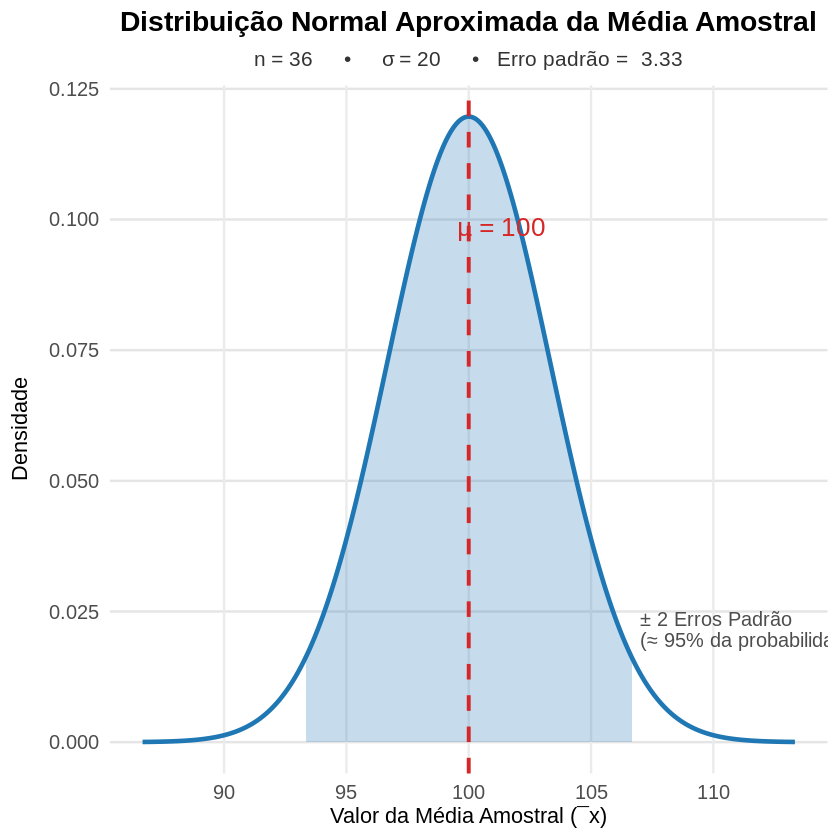

In [ ]:
# ================================================
# Exemplo 12: Distribuição Normal Aproximada da Média Amostral (ggplot2)
# ================================================

library(ggplot2)

# Parâmetros
mu    <- 100      # média populacional
sigma <- 20       # desvio padrão populacional
n     <- 36       # tamanho da amostra
se    <- sigma / sqrt(n)   # erro padrão da média

# Gerar dados para a curva
x_vals <- seq(mu - 4*se, mu + 4*se, length.out = 500)
dens   <- dnorm(x_vals, mean = mu, sd = se)

# Dados para sombrear a região ±2 erros padrão
x_fill <- seq(mu - 2*se, mu + 2*se, length.out = 200)
y_fill <- dnorm(x_fill, mean = mu, sd = se)

# Gráfico com ggplot2
ggplot() +
  # Curva principal
  geom_line(aes(x = x_vals, y = dens),
            color = "#1f77b4", linewidth = 1.3) +

  # Sombreamento da área ±2 se (≈95%)
  geom_area(aes(x = x_fill, y = y_fill),
            fill = "#1f77b4", alpha = 0.25) +

  # Linha vertical na média populacional
  geom_vline(xintercept = mu,
             color = "#d62728", linetype = "dashed", linewidth = 1.1) +

  # Anotações
  annotate("text", x = mu + 0.4*se, y = 0.82 * max(dens),
           label = expression(mu == 100),
           color = "#d62728", size = 5.5, fontface = "bold") +

  annotate("text", x = mu + 2.1*se, y = 0.18 * max(dens),
           label = "± 2 Erros Padrão\n(≈ 95% da probabilidade)",
           color = "gray30", size = 4.2, hjust = 0, lineheight = 0.9) +

  # Rótulos e títulos
  labs(title = "Distribuição Normal Aproximada da Média Amostral",
       subtitle = bquote(n == .(n) ~ "   •   " ~ sigma == .(sigma) ~
                        "   •   Erro padrão =" ~ .(round(se, 2))),
       x = "Valor da Média Amostral (¯x)",
       y = "Densidade") +

  # Tema limpo e elegante
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 12.5, hjust = 0.5, color = "gray20"),
    axis.title = element_text(size = 13),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "gray90")
  )

# **Exemplo 03: Área de Probabilidade sob a Distribuição Normal**

**Enunciado:**  
Calcule graficamente a probabilidade **P(x̄ < 168)**, onde x̄ é a média amostral.

### Parâmetros utilizados:
- Média populacional (μ) = 170  
- Desvio padrão populacional (σ) = 10  
- Tamanho da amostra (n) = 50  

**Erro padrão da média:** ≈ 1.414

**Resultado:**  
P(x̄ < 168) ≈ 0.1587 (ou aproximadamente 15,87%)

**Código R (ggplot2):**



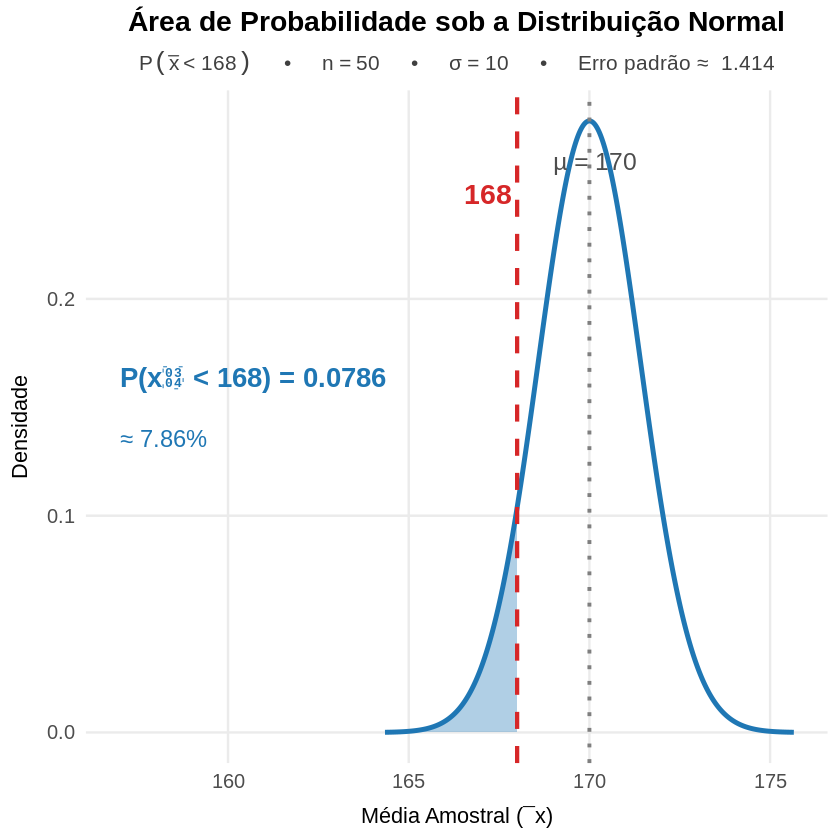

In [ ]:
# ================================================
# Exemplo 13: Área de Probabilidade - P(x̄ < 168)  (ggplot2)
# ================================================

library(ggplot2)

# Parâmetros
mu    <- 170      # média populacional
sigma <- 10       # desvio padrão populacional
n     <- 50       # tamanho da amostra
se    <- sigma / sqrt(n)   # erro padrão ≈ 1.4142

# Gera os dados para a curva
x_vals <- seq(mu - 4*se, mu + 4*se, length.out = 500)
y_vals <- dnorm(x_vals, mean = mu, sd = se)

# Dados para sombrear a região x < 168
x_fill <- seq(mu - 4*se, 168, length.out = 300)
y_fill <- dnorm(x_fill, mean = mu, sd = se)

# Probabilidade exata
prob <- pnorm(168, mean = mu, sd = se)

# Gráfico com ggplot2
ggplot() +
  # Curva da distribuição normal
  geom_line(aes(x = x_vals, y = y_vals),
            color = "#1f77b4", linewidth = 1.4) +

  # Área sombreada: P(x̄ < 168)
  geom_area(aes(x = x_fill, y = y_fill),
            fill = "#1f77b4", alpha = 0.35) +

  # Linha vertical em x = 168
  geom_vline(xintercept = 168,
             color = "#d62728", linetype = "dashed", linewidth = 1.2) +

  # Linha vertical na média (μ = 170)
  geom_vline(xintercept = mu,
             color = "gray50", linetype = "dotted", linewidth = 1.1) +

  # Anotações
  annotate("text",
           x = 168, y = max(y_vals) * 0.88,
           label = "168",
           color = "#d62728",
           size = 6,
           fontface = "bold",
           hjust = 1.1) +

  annotate("text",
           x = mu + 0.15, y = max(y_vals) * 0.93,
           label = expression(mu == 170),
           color = "gray30",
           size = 5.2,
           fontface = "bold") +

  annotate("text",
           x = 157, y = max(y_vals) * 0.58,
           label = paste("P(x̄ < 168) =", round(prob, 4)),
           color = "#1f77b4",
           size = 5.8,
           fontface = "bold",
           hjust = 0) +

  annotate("text",
           x = 157, y = max(y_vals) * 0.48,
           label = paste0("≈ ", round(prob*100, 2), "%"),
           color = "#1f77b4",
           size = 5,
           hjust = 0) +

  # Títulos e rótulos
  labs(title = "Área de Probabilidade sob a Distribuição Normal",
       subtitle = bquote(P(bar(x) < 168) ~ "   •   " ~
                        n == .(n) ~ "   •   " ~
                        sigma == .(sigma) ~ "   •   " ~
                        "Erro padrão ≈" ~ .(round(se, 3))),
       x = "Média Amostral (¯x)",
       y = "Densidade") +

  # Tema elegante
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 12.5, hjust = 0.5, color = "gray25"),
    axis.title.x = element_text(size = 13, margin = margin(t = 10)),
    axis.title.y = element_text(size = 13),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "gray92")
  )

# **Exemplo 04: Distribuição Normal Padrão (Z)**

**Enunciado:**  
Represente graficamente a distribuição normal padrão (Z ~ N(0, 1)) e destaque as áreas clássicas segundo a Regra Empírica.

### Interpretação:
- Média = 0 e desvio padrão = 1
- Aproximadamente 68% dos valores estão entre -1 e +1
- Aproximadamente 95% dos valores estão entre -2 e +2
- Aproximadamente 99,7% dos valores estão entre -3 e +3

**Código R (ggplot2):**

```r
# (insira aqui o código ggplot2 acima)

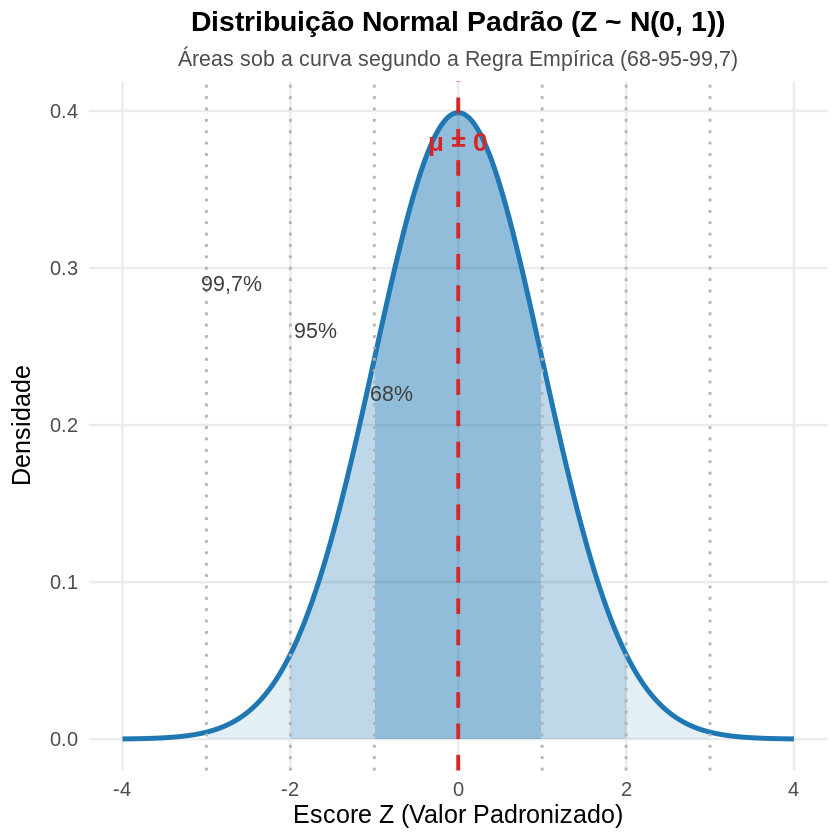

In [ ]:
# ================================================
# Exemplo 14: Distribuição Normal Padrão (ggplot2)
# ================================================

library(ggplot2)

z <- seq(-4, 4, length.out = 500)
dens <- dnorm(z)

# Data frame para áreas
df_area <- data.frame(
  z = z,
  dens = dens
)

ggplot(df_area, aes(x = z, y = dens)) +
  # Sombreamento das áreas clássicas
  geom_area(data = subset(df_area, z >= -3 & z <= 3),
            fill = "#1f77b4", alpha = 0.12) +
  geom_area(data = subset(df_area, z >= -2 & z <= 2),
            fill = "#1f77b4", alpha = 0.18) +
  geom_area(data = subset(df_area, z >= -1 & z <= 1),
            fill = "#1f77b4", alpha = 0.28) +

  # Curva principal
  geom_line(color = "#1f77b4", linewidth = 1.4) +

  # Linha vertical em z = 0
  geom_vline(xintercept = 0, color = "#d62728", linetype = "dashed", linewidth = 1.1) +

  # Linhas verticais em ±1, ±2, ±3
  geom_vline(xintercept = c(-3, -2, -1, 1, 2, 3),
             color = "gray70", linetype = "dotted", linewidth = 0.8) +

  # Anotações
  annotate("text", x = 0, y = 0.38, label = "μ = 0",
           color = "#d62728", size = 5.5, fontface = "bold") +
  annotate("text", x = -2.7, y = 0.29, label = "99,7%", size = 4.5, color = "gray25") +
  annotate("text", x = -1.7, y = 0.26, label = "95%",  size = 4.5, color = "gray25") +
  annotate("text", x = -0.8, y = 0.22, label = "68%",  size = 4.5, color = "gray25") +

  labs(title = "Distribuição Normal Padrão (Z ~ N(0, 1))",
       subtitle = "Áreas sob a curva segundo a Regra Empírica (68-95-99,7)",
       x = "Escore Z (Valor Padronizado)",
       y = "Densidade") +

  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 12.8, hjust = 0.5, color = "gray30"),
    panel.grid.minor = element_blank()
  )

# **Exemplo 15: Variável Bernoulli**

**Enunciado:**  
Simule uma variável Bernoulli com probabilidade de sucesso **p = 0.6** e visualize sua distribuição empírica com 1000 simulações.

### Parâmetros:
- Probabilidade de sucesso (p) = 0.6  
- Número de simulações = 1000

### Interpretação:
- Espera-se aproximadamente **600 sucessos** (1) e **400 fracassos** (0).
- A distribuição Bernoulli é a mais simples das distribuições discretas: apenas dois possíveis resultados.



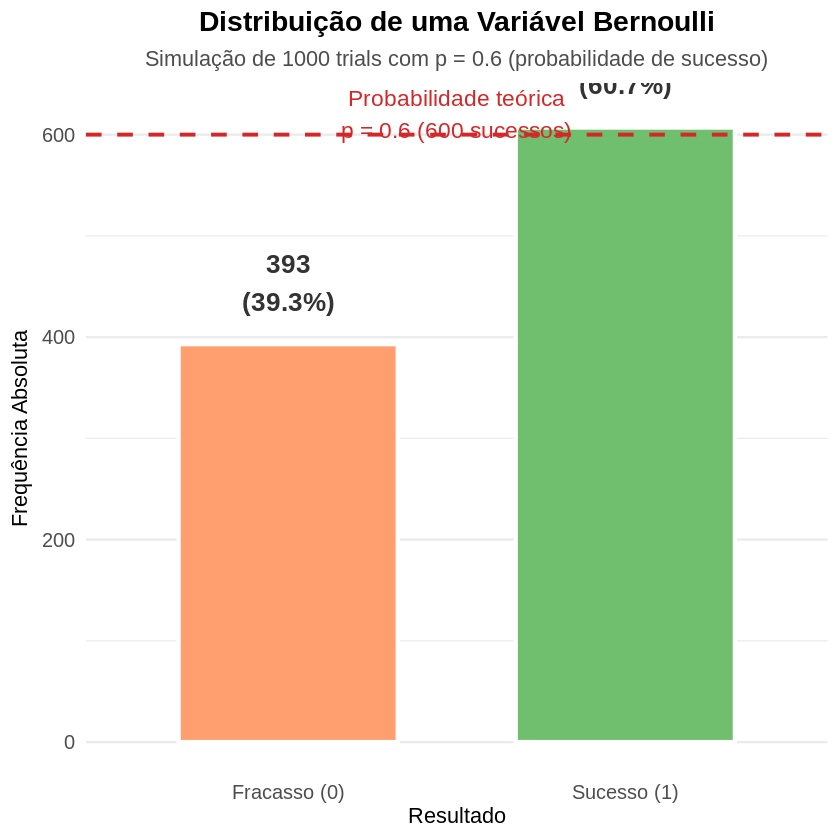

In [ ]:
# ================================================
# Exemplo 15: Variável Bernoulli (p = 0.6)
# ================================================

library(ggplot2)
set.seed(123)  # para reprodutibilidade

# Simulação de 1000 trials Bernoulli (sucesso = 1, fracasso = 0)
dados <- rbinom(n = 1000, size = 1, prob = 0.6)

# Criar data frame para ggplot2
df <- data.frame(
  resultado = factor(dados, levels = c(0, 1),
                     labels = c("Fracasso (0)", "Sucesso (1)"))
)

# Calcular proporções
prop <- prop.table(table(dados))
prop_df <- data.frame(
  resultado = factor(c(0,1), levels = c(0,1),
                     labels = c("Fracasso (0)", "Sucesso (1)")),
  proporcao = as.numeric(prop),
  contagem = as.numeric(table(dados))
)

# Gráfico com ggplot2
ggplot(prop_df, aes(x = resultado, y = contagem, fill = resultado)) +
  geom_col(width = 0.65, color = "white", linewidth = 1.2) +
  geom_text(aes(label = paste0(contagem, "\n(", round(proporcao*100, 1), "%)")),
            vjust = -0.6,
            size = 5.5,
            fontface = "bold",
            color = "gray20") +

  scale_fill_manual(values = c("#ff9f6f", "#6fbf6f")) +

  labs(title = "Distribuição de uma Variável Bernoulli",
       subtitle = "Simulação de 1000 trials com p = 0.6 (probabilidade de sucesso)",
       x = "Resultado",
       y = "Frequência Absoluta") +

  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 13, hjust = 0.5, color = "gray30"),
    legend.position = "none",
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 13),
    panel.grid.major.x = element_blank()
  ) +
  # Linha horizontal com probabilidade teórica
  geom_hline(yintercept = 1000 * 0.6,
             linetype = "dashed",
             color = "#d62728",
             linewidth = 1.1) +
  annotate("text", x = 1.5, y = 620,
           label = "Probabilidade teórica\np = 0.6 (600 sucessos)",
           color = "#d62728",
           size = 4.8,
           hjust = 0.5)